<a href="https://colab.research.google.com/github/angelagdca/GDP_first_model/blob/main/GDP_model_firstry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PIB España (BISTRO)**

In [ ]:
#Solo 1 vez para no romper el entorno
!pip uninstall -y numpy pandas scipy gluonts uni2ts
!pip install --no-cache-dir --force-reinstall \
    numpy==1.26.4 \
    pandas==2.1.4 \
    scipy==1.11.4
!pip install --no-cache-dir gluonts
!pip install --no-cache-dir uni2ts

###**Step 1**

Preparar el entorno y las librerías necesarias para ejecutar BISTRO/Moirai.

In [2]:
#Deja listo el entorno para usar BISTRO/Moirai

import os
import sys
import subprocess
from pathlib import Path

#Compatibilidad de NumPy (sobre todo en Google Colab)
try:
    import numpy as np

    if np.__version__.startswith("2."):
        print(f"Current NumPy is {np.__version__}. Downgrading to 1.26.4...")

        subprocess.run([
            "pip", "install", "-q", "--force-reinstall",
            "numpy==1.26.4",
            "pandas==2.1.4",
            "scipy==1.11.4",
            "opencv-python==4.8.0.76"
        ], check=True)

        print("✅ Install complete. Restarting runtime automatically...")
        os.kill(os.getpid(), 9)

    else:
        print(f"✅ Success! Using NumPy version: {np.__version__}")

except Exception as e:
    print(f"NumPy compatibility check skipped/error: {e}")

#Si estás en Google Colab: clonar repo e instalar deps

if 'google.colab' in sys.modules:
    print("Running in Google Colab. Cloning BISTRO repo...")

    if not os.path.exists("/content/bistro"):
        !git clone -q https://github.com/bis-med-it/bistro.git

    print("Installing project dependencies...")
    !pip install -q -r /content/bistro/requirements.txt

    print("✅ Repository and dependencies ready.")

✅ Success! Using NumPy version: 1.26.4
Running in Google Colab. Cloning BISTRO repo...
Installing project dependencies...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
pointpats 2.5.5 requires pandas>=2.2, but you have pandas 2.1.4 which is incompatible.
pointpats 2.5.5 requires scipy>=1.12, but you have scipy 1.11.4 which is incompatible.
mizani 0.13.5 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydantic 2.12.5 which is incompatible.
giddy 2.3.8 requires scipy>=1.12, but you have scipy 1.11.4 which is inco

In [3]:
#Ajustar rutas del proyecto

if 'google.colab' in sys.modules:
    project_root = Path("/content/bistro")
else:
    # Cambia esta ruta si trabajas en local
    project_root = Path.cwd()

repo_root = project_root
src_root = repo_root / "src"
script_root = repo_root / "script"

if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

if str(script_root) not in sys.path:
    sys.path.insert(0, str(script_root))

print("repo_root:", repo_root)
print("src_root:", src_root)
print("script_root:", script_root)

#Imports principales
import numpy as np
import pandas as pd

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

from inference_util import plot_publication_forecast_comparison
from preprocessing_util import (
    aggregate_daily_forecast_to_monthly,
    prepare_yoy_monthly_for_daily_inference,
)

print("✅ Core imports loaded successfully.")

repo_root: /content/bistro
src_root: /content/bistro/src
script_root: /content/bistro/script
✅ Core imports loaded successfully.


###**Step 2**

Cargar el PIB de España desde FRED, limpiarlo y transformarlo en crecimiento trimestral (gdp_qoq).

Vemos si mi colab tiene acceso a mi repo

In [4]:
from pathlib import Path
import os

repo_root = Path("/content/GDP_first_model")

if not repo_root.exists():
    !git clone https://github.com/angelagdca/GDP_first_model.git /content/GDP_first_model

print("repo_root:", repo_root)
print("repo exists:", repo_root.exists())
print("files in repo:", os.listdir(repo_root))

repo_root: /content/GDP_first_model
repo exists: True
files in repo: ['.git', 'GDP_model_firstry.ipynb', 'README', 'data']


Comprobamos si está la carpeta "data" y que mi CSV está dentro

In [5]:
from pathlib import Path
import os

repo_root = Path("/content/GDP_first_model")
data_dir = repo_root / "data"

print("data_dir:", data_dir)
print("data exists:", data_dir.exists())

if data_dir.exists():
    print("files in data:", os.listdir(data_dir))

data_dir: /content/GDP_first_model/data
data exists: True
files in data: ['.gitkeep', 'GDP_FRED_SPAIN.csv']


Leemos el CSV y vemos cómo vienen las columnas

In [6]:
import pandas as pd

series1 = repo_root / "data" / "GDP_FRED_SPAIN.csv"
df_raw = pd.read_csv(series1)

print(df_raw.head())
print(df_raw.columns.tolist())

  observation_date  CLVMNACSCAB1GQES
0       1995-01-01          178588.8
1       1995-04-01          179766.0
2       1995-07-01          180561.7
3       1995-10-01          181928.6
4       1996-01-01          182974.5
['observation_date', 'CLVMNACSCAB1GQES']


Limpiamos y preparamos la serie de PIB

In [7]:
import pandas as pd

series1 = repo_root / "data" / "GDP_FRED_SPAIN.csv"
df = pd.read_csv(series1)

#Renombrar columnas
df = df.rename(columns={
    "observation_date": "date",
    "CLVMNACSCAB1GQES": "gdp_real"
})

#Convertir fecha
df["date"] = pd.to_datetime(df["date"])

#Ordenar e indexar
df = df.sort_values("date").set_index("date")

#Crear crecimiento trimestral del PIB en %
df["gdp_qoq"] = df["gdp_real"].pct_change() * 100

#Frecuencia trimestral
FREQ = "Q"
df.index = df.index.to_period(FREQ)

#Serie objetivo
target_col = "gdp_qoq"
df_target = df[[target_col]].dropna().copy()

# Comprobaciones
print("Número de observaciones:", len(df_target))
print()
print(df_target.head())
print()
print(df_target.tail())

print(df[["gdp_real", "gdp_qoq"]].head(10))
df_target
target_col = "gdp_qoq"

Número de observaciones: 123

         gdp_qoq
date            
1995Q2  0.659168
1995Q3  0.442631
1995Q4  0.757027
1996Q1  0.574896
1996Q2  0.691353

         gdp_qoq
date            
2024Q4  0.813581
2025Q1  0.458506
2025Q2  0.730101
2025Q3  0.635936
2025Q4  0.769923
        gdp_real   gdp_qoq
date                      
1995Q1  178588.8       NaN
1995Q2  179766.0  0.659168
1995Q3  180561.7  0.442631
1995Q4  181928.6  0.757027
1996Q1  182974.5  0.574896
1996Q2  184239.5  0.691353
1996Q3  185750.8  0.820291
1996Q4  186674.9  0.497494
1997Q1  188536.4  0.997188
1997Q2  190237.4  0.902213


###**Step 3**

Definir la estructura del forecast: horizonte, ventana histórica y división entre train y test.

- Horizonte de forecast
- Longitud de contexto
- Serie objetivo en el formato correcto
- Punto desde el que queremos predecir

Frequency: Q
Prediction length: 4
Context length: 80

Serie objetivo:
date
1995Q2    0.659168
1995Q3    0.442631
1995Q4    0.757027
1996Q1    0.574896
1996Q2    0.691353
Freq: Q-DEC, Name: gdp_qoq, dtype: float64
date
2024Q4    0.813581
2025Q1    0.458506
2025Q2    0.730101
2025Q3    0.635936
2025Q4    0.769923
Freq: Q-DEC, Name: gdp_qoq, dtype: float64

Último dato observado: 2025Q4
Forecast empieza en: 2026Q1


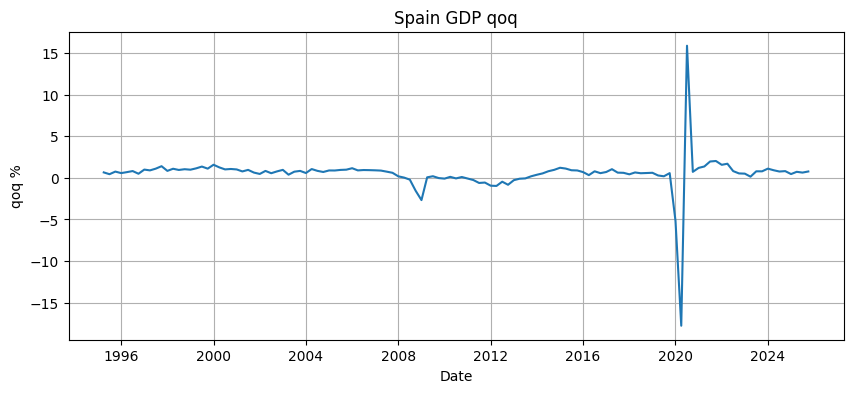

In [8]:
import matplotlib.pyplot as plt

#Parámetros del forecast
FREQ = "Q"
PDT = 4  #prediction length: 4 trimestres
CTX = 80 #context length: 80 trimestres
BSZ = 32
PSZ = 32

print("Frequency:", FREQ)
print("Prediction length:", PDT)
print("Context length:", CTX)

#Serie objetivo final
ts = df_target[target_col].copy()

print()
print("Serie objetivo:")
print(ts.head())
print(ts.tail())

#Elegimos el punto desde el que queremos empezar a forecastar

#Primer experimento: forecast al final de la muestra
forecast_start = ts.index[-1] + 1

print()
print("Último dato observado:", ts.index[-1])
print("Forecast empieza en:", forecast_start)

#Visualización rápida de la serie
plt.figure(figsize=(10, 4))
plt.plot(ts.index.to_timestamp(), ts.values)
plt.title("Spain GDP qoq")
plt.xlabel("Date")
plt.ylabel("qoq %")
plt.grid(True)
plt.show()

Convertimos la serie trimestral a un dataframe compatible con el pipeline de forecasting

In [ ]:
!pip install gluonts
from gluonts.dataset.pandas import PandasDataset

In [10]:
# Serie en formato timestamp para gluonts
ts_df = ts.to_timestamp().to_frame(name=target_col)

dataset = PandasDataset(ts_df)

print(dataset)
print()
print(ts_df.head())
print(ts_df.tail())

PandasDataset<size=1, freq=QS-OCT, num_feat_dynamic_real=0, num_past_feat_dynamic_real=0, num_feat_static_real=0, num_feat_static_cat=0, static_cardinalities=[]>

             gdp_qoq
date                
1995-04-01  0.659168
1995-07-01  0.442631
1995-10-01  0.757027
1996-01-01  0.574896
1996-04-01  0.691353
             gdp_qoq
date                
2024-10-01  0.813581
2025-01-01  0.458506
2025-04-01  0.730101
2025-07-01  0.635936
2025-10-01  0.769923


In [11]:
#separamos en train y test para preparar y entrenar el modelo

#Reservamos los últimos 4 trimestres como "test"
train_ts = ts.iloc[:-PDT].copy()
test_ts = ts.iloc[-PDT:].copy()

print("Train observations:", len(train_ts))
print("Test observations:", len(test_ts))
print()
print("Último dato train:", train_ts.index[-1])
print("Primer dato test:", test_ts.index[0])
print()
print(test_ts)

Train observations: 119
Test observations: 4

Último dato train: 2024Q4
Primer dato test: 2025Q1

date
2025Q1    0.458506
2025Q2    0.730101
2025Q3    0.635936
2025Q4    0.769923
Freq: Q-DEC, Name: gdp_qoq, dtype: float64


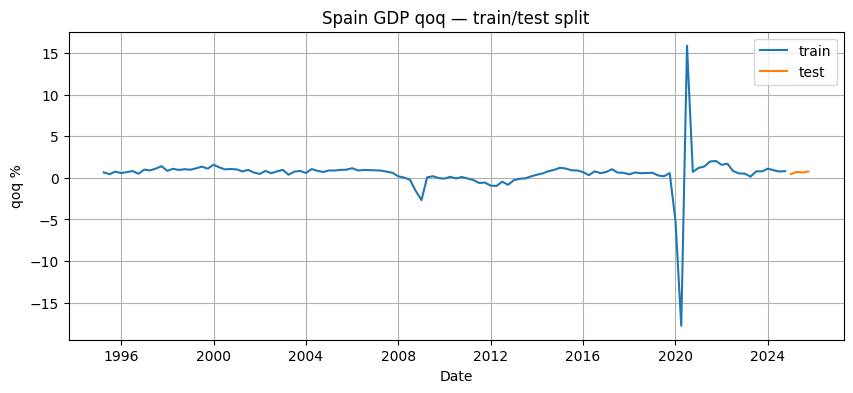

In [12]:
#Visualizamos el split

plt.figure(figsize=(10, 4))
plt.plot(train_ts.index.to_timestamp(), train_ts.values, label="train")
plt.plot(test_ts.index.to_timestamp(), test_ts.values, label="test")
plt.title("Spain GDP qoq — train/test split")
plt.xlabel("Date")
plt.ylabel("qoq %")
plt.grid(True)
plt.legend()
plt.show()

###**Step 4**

Ejecutar la predicción con BISTRO sobre el PIB de España y comparar el forecast con los datos reales.

In [13]:
import os
from pathlib import Path

if not Path("/content/bistro").exists():
    !git clone -q https://github.com/bis-med-it/bistro.git /content/bistro

!pip install -q -r /content/bistro/requirements.txt

In [14]:
import os
import sys
from pathlib import Path

os.chdir("/content/bistro/script")

repo_root_bistro = Path("..").resolve()
src_root = Path("../src").resolve()

if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print("repo_root_bistro:", repo_root_bistro)
print("src_root:", src_root)

repo_root_bistro: /content/bistro
src_root: /content/bistro/src


In [15]:
#IMPORTS

import numpy as np
import pandas as pd

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

Como todavía no estamos usando el preprocesado mensual especial de BISTRO, vamos a hacer una versión simple y limpia sobre tu serie trimestral gdp_qoq.

In [21]:
PDT = 4   # 4 trimestres hacia delante
CTX = 80  # 80 trimestres de historia
PSZ = 1   # para serie trimestral simple
BSZ = 32

ts = df_target[target_col].copy()

train_ts = ts.iloc[:-PDT].copy()
test_ts = ts.iloc[-PDT:].copy()

print("Último dato train:", train_ts.index[-1])
print("Test real:")
print(test_ts)


Último dato train: 2024Q4
Test real:
date
2025Q1    0.458506
2025Q2    0.730101
2025Q3    0.635936
2025Q4    0.769923
Freq: Q-DEC, Name: gdp_qoq, dtype: float64


In [26]:
#Convierto a datetime

train_df = train_ts.copy()
train_df.index = train_df.index.to_timestamp(how="end")
train_df = train_df.to_frame(name="target")

print(train_df.head())
print(train_df.tail())

                                 target
date                                   
1995-06-30 23:59:59.999999999  0.659168
1995-09-30 23:59:59.999999999  0.442631
1995-12-31 23:59:59.999999999  0.757027
1996-03-31 23:59:59.999999999  0.574896
1996-06-30 23:59:59.999999999  0.691353
                                 target
date                                   
2023-12-31 23:59:59.999999999  0.788438
2024-03-31 23:59:59.999999999  1.113120
2024-06-30 23:59:59.999999999  0.918936
2024-09-30 23:59:59.999999999  0.765173
2024-12-31 23:59:59.999999999  0.813581


In [23]:
from gluonts.dataset.pandas import PandasDataset

In [27]:
#Creo el dataset simple

ds_pred = PandasDataset(train_df)
print("Dataset preparado")

Dataset preparado


In [33]:
#Lanzo el forecast

#Cargo el modelo BISTRO / Moirai y creo el predictor

MODEL_REPO = repo_root_bistro / "bistro-finetuned"

model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(str(MODEL_REPO)),
    prediction_length=PDT,
    context_length=CTX,
    patch_size=PSZ,
    num_samples=100,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)

predictor = model.create_predictor(batch_size=BSZ)

print("Modelo cargado correctamente.")

Loading weights from local directory
Modelo cargado correctamente.


In [34]:
forecasts = list(predictor.predict(ds_pred))

print("Número de forecasts:", len(forecasts))

Número de forecasts: 1


In [32]:
import numpy as np
import pandas as pd

In [29]:
#extraigo la predicción media

samples = np.asarray(forecasts[0].samples, dtype=float)
pred_mean = samples.mean(axis=0)

forecast_index = test_ts.index

df_pred = pd.DataFrame(
    {
        "actual": test_ts.values,
        "bistro_pred": pred_mean,
    },
    index=forecast_index
)

print(df_pred)

          actual  bistro_pred
date                         
2025Q1  0.458506     2.096942
2025Q2  0.730101     1.727472
2025Q3  0.635936     1.294522
2025Q4  0.769923     1.293171


In [30]:
#Error simple

rmse = np.sqrt(((df_pred["actual"] - df_pred["bistro_pred"]) ** 2).mean())
mae = np.abs(df_pred["actual"] - df_pred["bistro_pred"]).mean()

print("RMSE:", round(rmse, 4))
print("MAE :", round(mae, 4))

RMSE: 1.0472
MAE : 0.9544


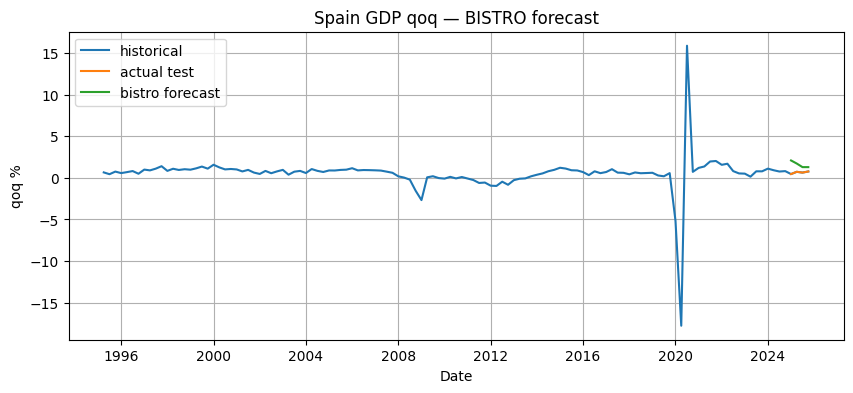

In [31]:
#Gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(ts.index.to_timestamp(), ts.values, label="historical")
plt.plot(df_pred.index.to_timestamp(), df_pred["actual"], label="actual test")
plt.plot(df_pred.index.to_timestamp(), df_pred["bistro_pred"], label="bistro forecast")

plt.title("Spain GDP qoq — BISTRO forecast")
plt.xlabel("Date")
plt.ylabel("qoq %")
plt.grid(True)
plt.legend()
plt.show()